In [1]:
import pandas as pd
import numpy as np

import tubesml as tml


import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

from source.report import report_points, report_victory, _point_to_proba


from sklearn.model_selection import KFold

from sklearn.linear_model import Ridge, LogisticRegression, Lasso
from sklearn.pipeline import Pipeline

import lightgbm as lgb
import xgboost as xgb

In [2]:
def train_predict(data, test_data, target, estimator, cv, test_target=None, fit_params=None, early_stopping=False, shap=True, result_compare=None):
    cv_score = tml.CrossValidate(data=data, target=target, test=test_data,
                                 estimator=estimator, cv=cv, fit_params=fit_params, early_stopping=early_stopping,
                                shap=shap, imp_coef=True)

    oof, pred, result_dict = cv_score.score()

    score = np.sqrt(mean_squared_error(y_true=target, y_pred=oof))
    print(f"OOF score: {score}")

    if early_stopping:
        print(result_dict["iterations"])

    if shap:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="both", n=10)
        to_plot = result_dict["feat_imp"].head(10)["Feature"].to_list()
        tml.plot_shap_values(result_dict["shap_values"], features=to_plot)
    else:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="standard", n=10)

    tml.plot_regression_predictions(data=data, true_label=target, pred_label=oof, feature=["delta_Seed"])

    if result_compare is not None:
        baseline = result_compare["score"]
        ref_oof = result_compare["oof"]

        if score - baseline >= 0:
            print(f"This is {round((score - baseline) / baseline * 100, 3)}% worse than the baseline.")
        else:
            print(f"This is {round(-(score - baseline) / baseline * 100, 3)}% better than the baseline.")
    
        comparison = tml.CompareModels(data=data, true_label=target.reset_index(drop=True),
                                       pred_1=oof, pred_2=ref_oof,
                                       kfold=cv,
                                       regression=True,
                                       probabilities=True,
                                       metric_func=mean_squared_error)
    
        comparison.compare_metrics()
        comparison.compare_predictions()
        comparison.statistical_significance()

    if test_target is not None:
        score = np.sqrt(mean_squared_error(y_true=test_target, y_pred=pred))
        print(f"Test score: {score}")
        tml.plot_regression_predictions(data=test_data, true_label=test_target, pred_label=pred, feature=["delta_Seed"])

    return oof, pred, result_dict

In [3]:
df = pd.read_csv("data/processed/women_training.csv")

DROP = ["target", "target_points", "ID", "DayNum", "Team1", "Team2",
        'T1_Loc', 'T2_Loc',
                "T1_region", "T2_region", "Season", "delta_Loc",
                "Season", "competitive", "competitive_score",
                "delta_def_rating_diff", "delta_impact_diff",
                "T1_def_rating_diff", "T2_def_rating_diff"]


N_FOLDS = 5
kfolds = KFold(n_splits=N_FOLDS, shuffle=True, random_state=13)

df_train, df_test = tml.make_test(df, test_size=0.2, random_state=34)

In [12]:
result_dict["feat_imp"].head(20)


,Feature,shap_importance,shap_std,mean,std
0,delta_Seed,8.302765,0.102424,-10.309511,0.155903
1,delta_N_wins,4.831199,0.061378,-6.107639,0.235812
2,delta_elo,1.702784,0.023183,2.184021,0.110191
3,delta_opp_FTA,1.650812,0.024315,-2.148751,0.278752
4,delta_TO,1.571786,0.020622,-1.965103,0.164312
5,delta_impact,1.344778,0.020853,-1.742913,0.310232
6,delta_Blk,1.308530,0.019249,1.677408,0.237304
7,delta_DR_diff,1.264575,0.016674,1.585025,0.113629
8,delta_TO_perposs_diff,1.244809,0.015770,-1.555163,0.048226
9,delta_Tot_Reb_diff,1.215474,0.015952,1.538895,0.062330


OOF score: 12.421168684600945


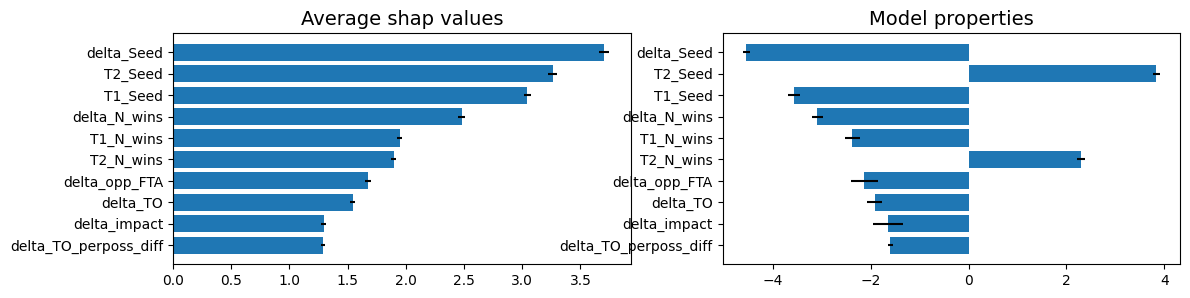

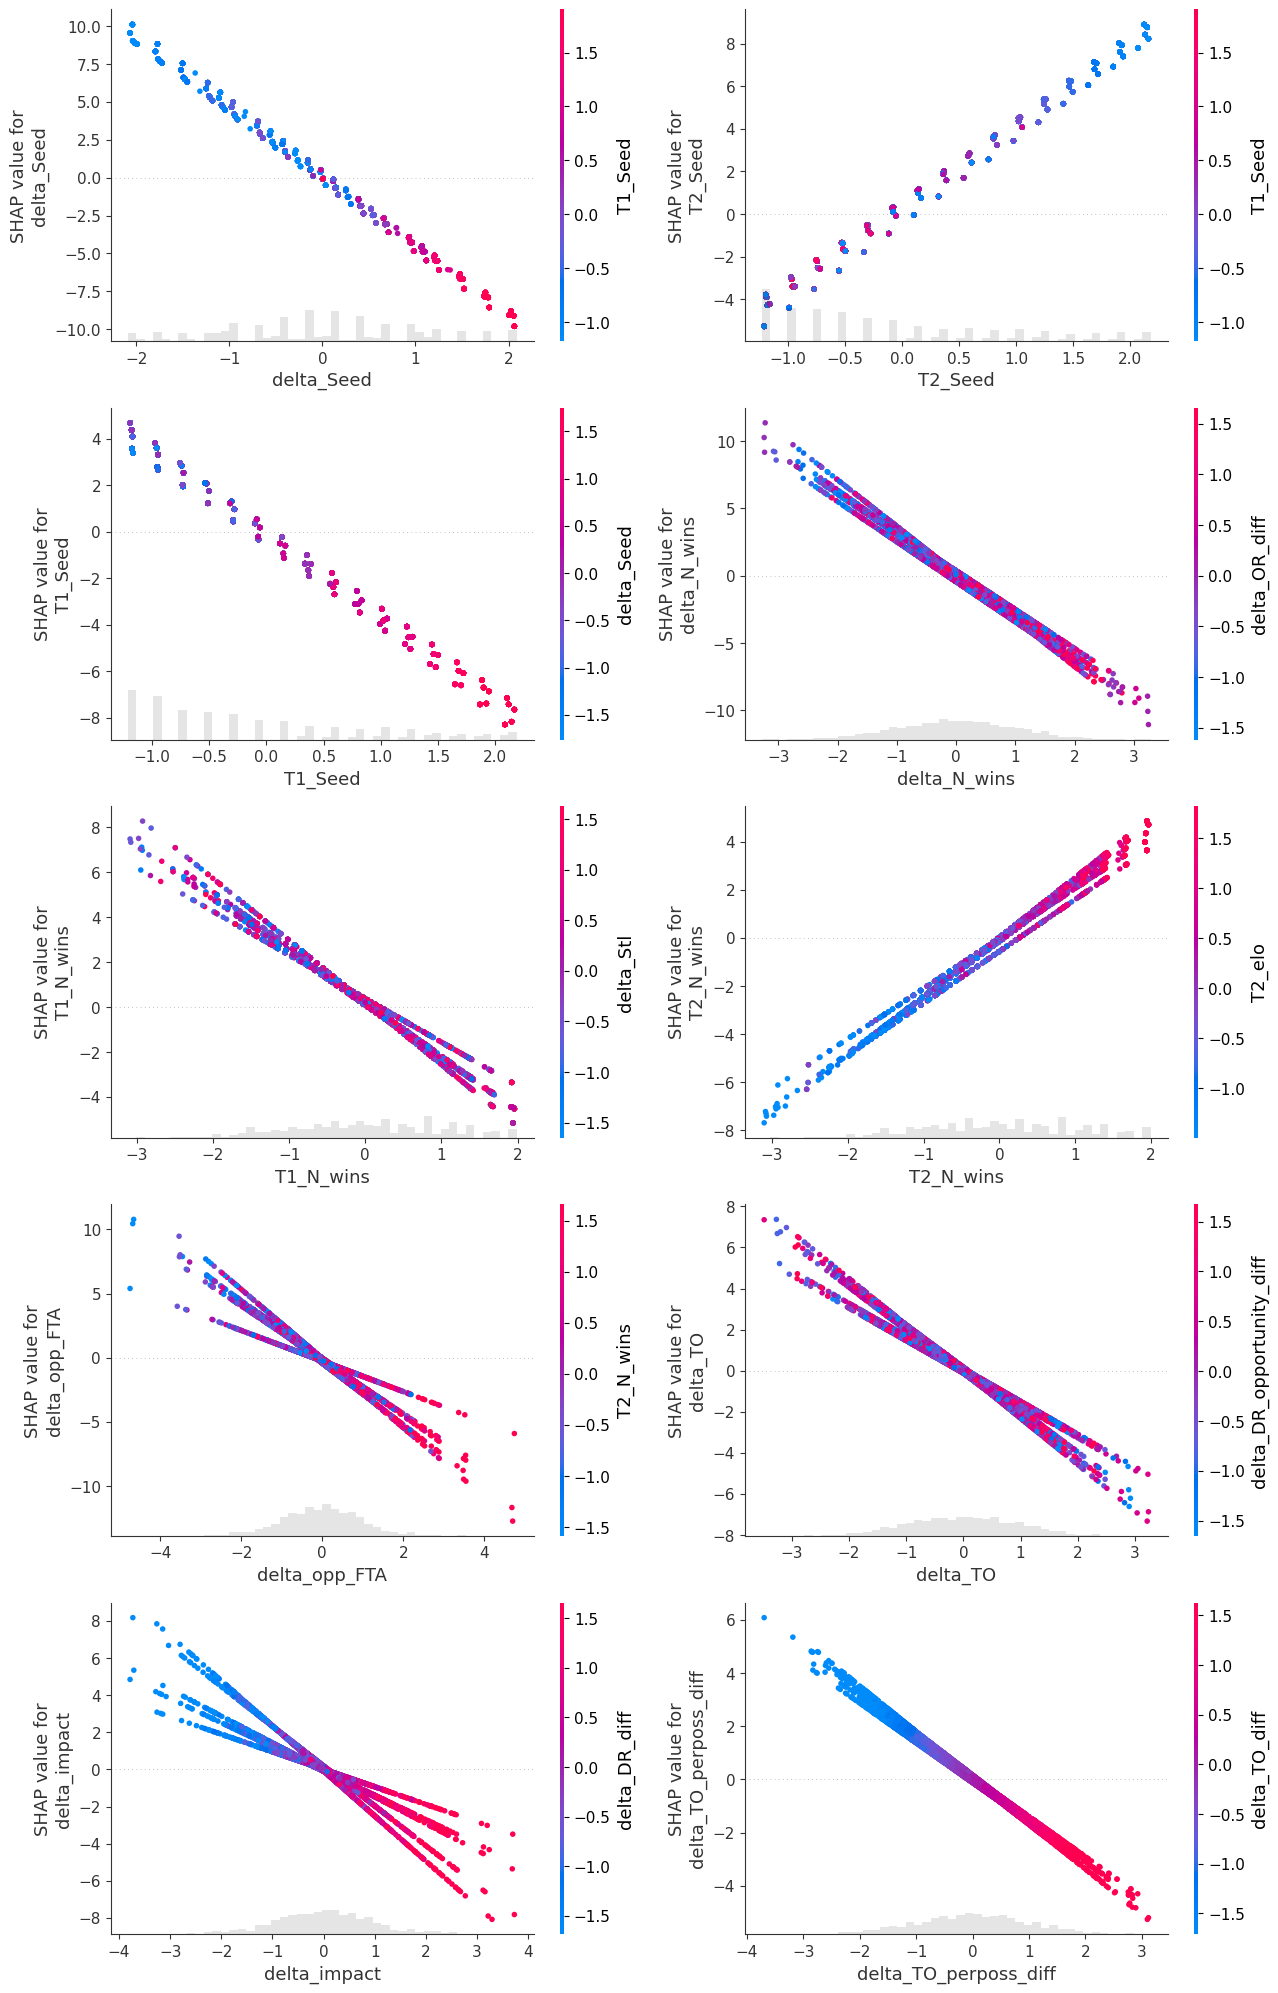

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


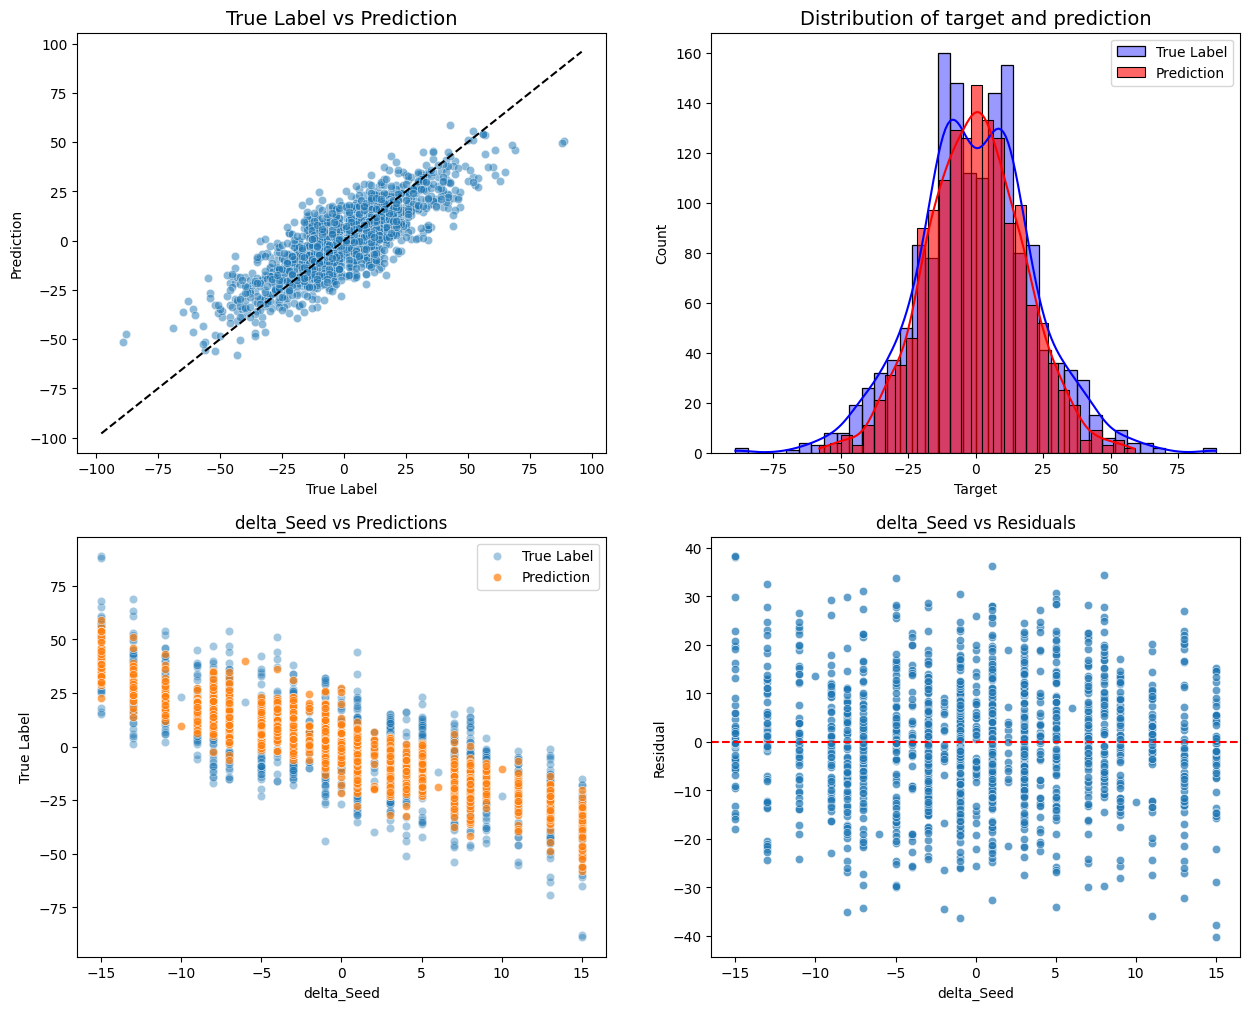

Test score: 12.286293329602957


use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


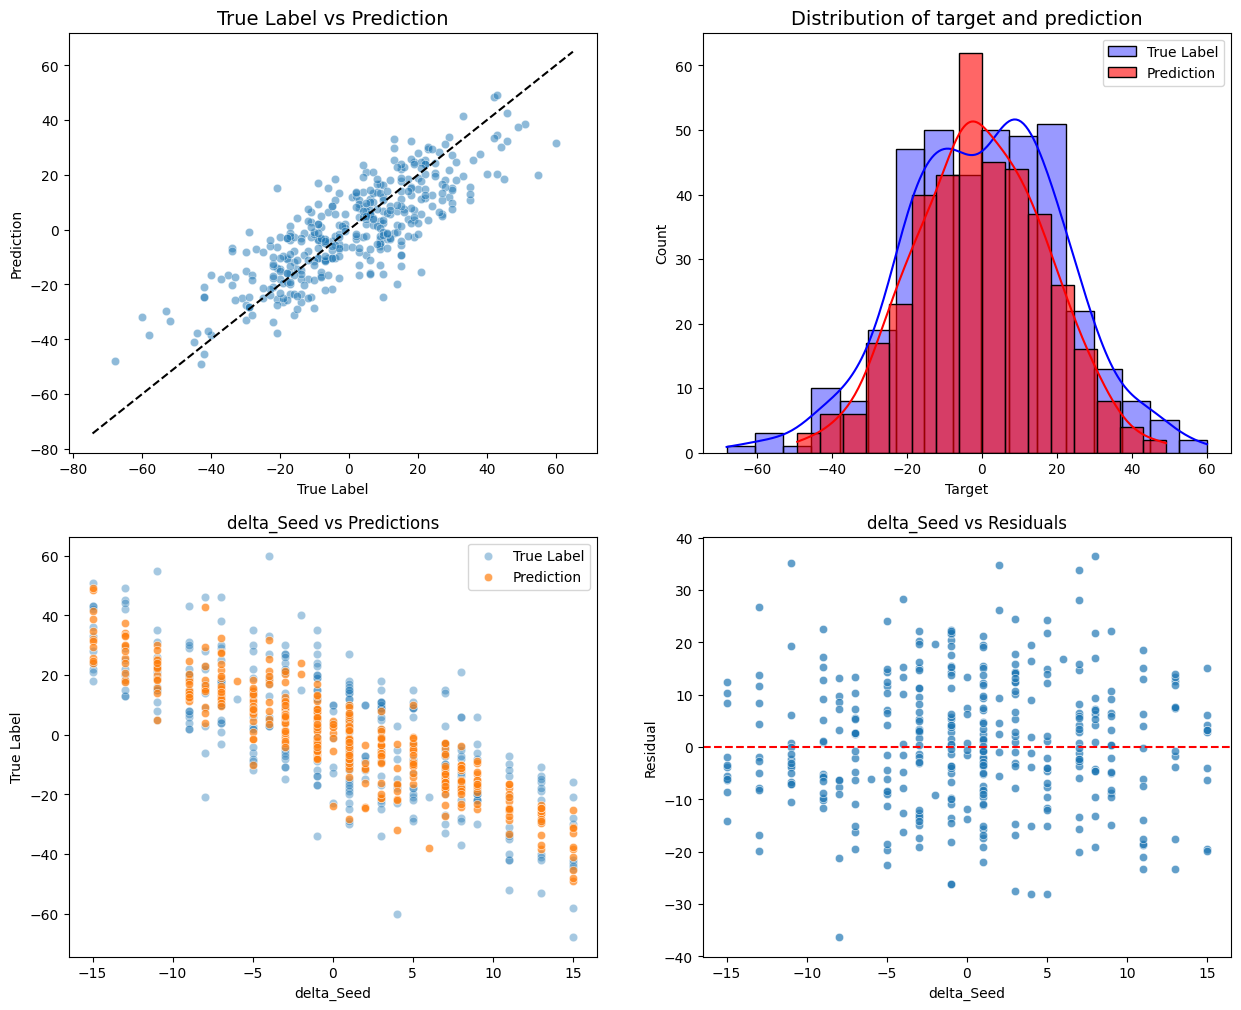

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


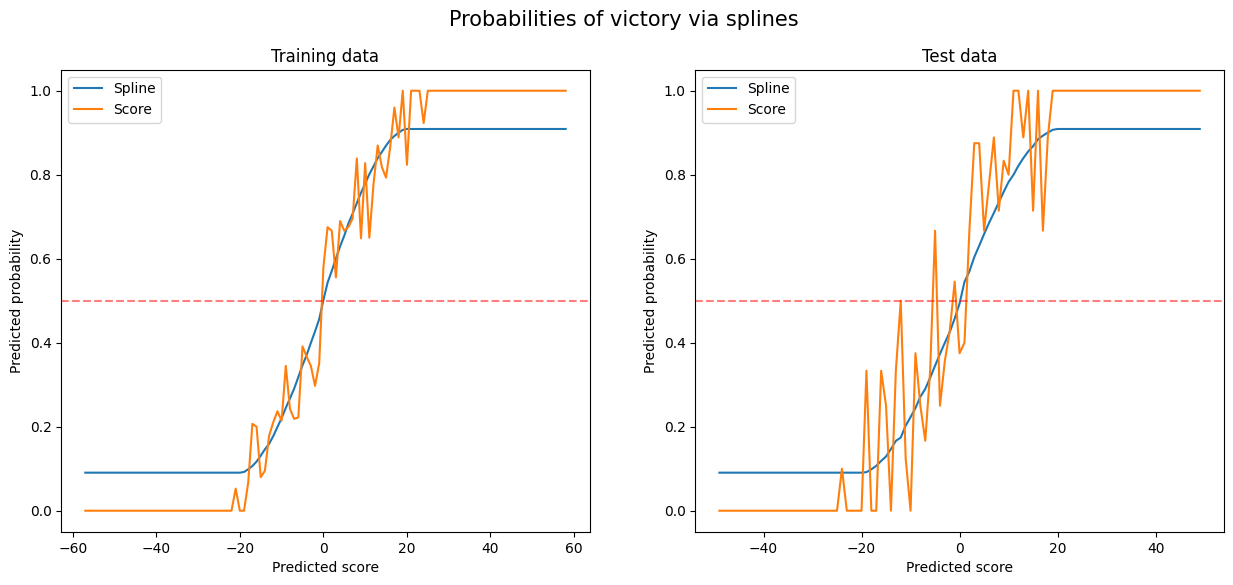

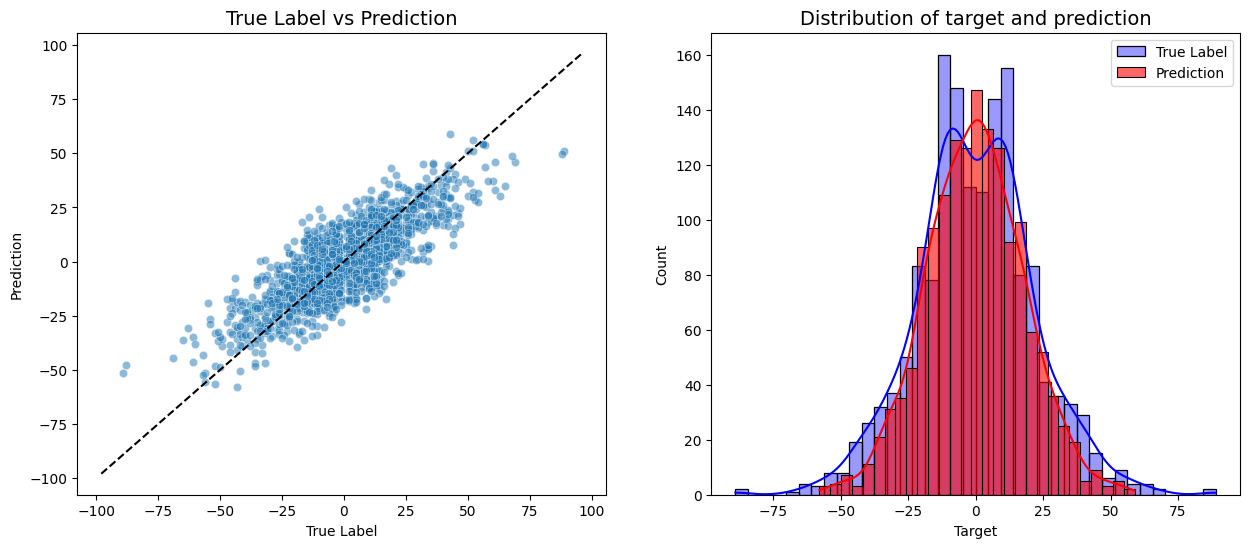

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


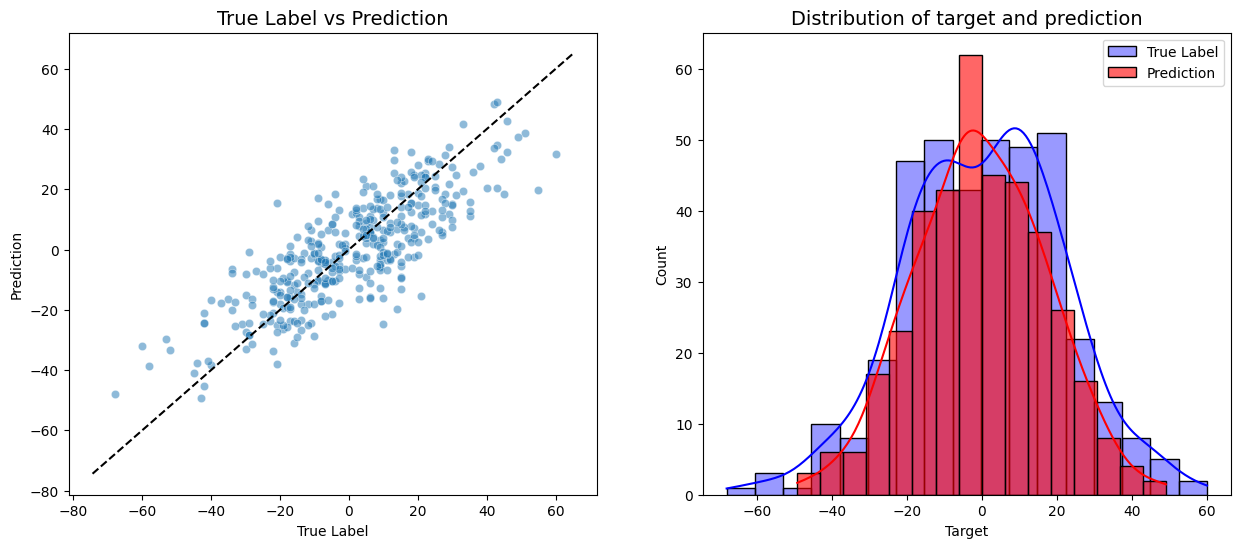

MAE train: 			 9.7844
MAE test: 			 9.8262
RMSE train: 			 12.4212
RMSE test: 			 12.2863
Accuracy train: 		 0.8051
Accuracy test: 			 0.8115
Logloss train: 			 0.4389
Logloss test: 			 0.4242
Brier train: 			 0.1411
Brier test: 			 0.134
Unsure train: 			 9.58%
Unsure test: 			 7.59%


,mae_oof,mae_test,mse_oof,mse_test,acc_oof,acc_test,logloss_oof,logloss_test,brier_oof,brier_test,unsure_oof,unsure_test
0,9.7844,9.8262,12.4212,12.2863,0.8051,0.8115,0.4389,0.4242,0.1411,0.134,9.58,7.59


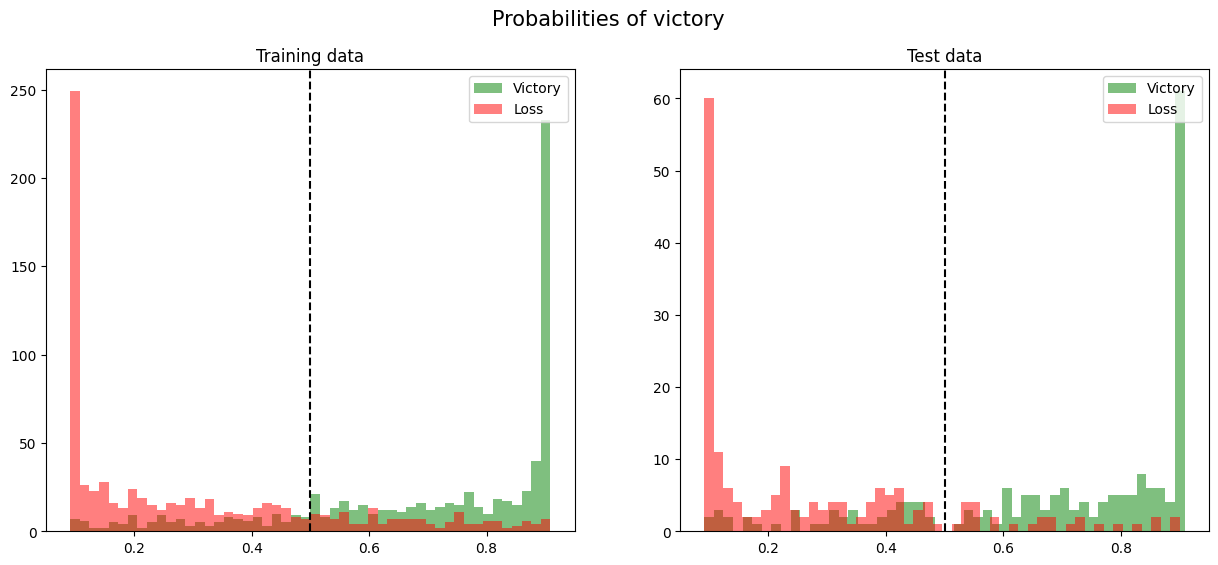

In [13]:
target = df_train["target_points"]

not_imp = ['delta_FTA',
 'delta_opp_FGM',
 'delta_DR',
 'delta_Ast_TO_ratio',
 'delta_opp_PF',
 'delta_FGM_no_ast_diff',
 'delta_FTM_diff',
 'delta_def_rating',
 'delta_OT_win',
 'delta_Tot_Reb',
 'delta_FGA',
 'delta_FGM_perc',
 'delta_possessions_diff',
 'delta_FT_perc',
 'delta_opp_FGA',
 'delta_possessions',
 'delta_opp_possessions',
 'delta_opp_score',
 'delta_True_shooting_perc_diff',
 'delta_quality']

extras = ["T1_Seed", "T2_Seed", "T1_elo", "T2_elo", "T1_N_wins", "T2_N_wins"]
FEATURES = [c for c in df_train if "delta" in c and c not in DROP and c not in not_imp] + extras
train = df_train[FEATURES].copy()
test_target = df_test["target_points"]
test = df_test[FEATURES].copy()

model = Ridge(random_state=34, alpha=21.8, max_iter=10000)

pipe = Pipeline([("scaler", tml.DfScaler()),
                ("model", model)])

oof, pred, result_dict = train_predict(data=train, test_data=test, target=target,
                                       estimator=pipe, cv=kfolds, test_target=test_target,
                                       fit_params=None, early_stopping=False,
                                       shap=True, result_compare=None)


report_points(train=df_train, test=df_test, y_train=target, y_test=test_target, oof=oof, preds=pred, clip_val=20, padd=0.005)

In [14]:
pred_oof, pred_test = _point_to_proba(oof=oof, y_train=df_train["target_points"], preds=pred, clip_val=20, padd=0.005)
df_train["oof"] = oof
df_train["oof_prob"] = pred_oof
df_test ["pred"] = pred
df_test["pred_prob"] = pred_test

df_train["abs_err_points"] = (df_train["target_points"] - df_train["oof"]).abs()
df_train["sqr_err_prob"] = (df_train["target"] - df_train["oof_prob"])**2
df_test["abs_err_points"] = (df_test["target_points"] - df_test["pred"]).abs()
df_test["sqr_err_prob"] = (df_test["target"] - df_test["pred_prob"])**2

In [15]:
df_train.groupby("stage_Round1")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round1,,
False,9.944680,0.164251
True,9.627064,0.118337


In [16]:
df_train.groupby("stage_Round2")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round2,,
False,9.643080,0.136578
True,10.196788,0.154227


In [17]:
df_train.groupby("stage_Round3")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round3,,
False,9.766875,0.137715
True,9.904649,0.164175


In [18]:
df_train.groupby("stage_Round4")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round4,,
False,9.802248,0.139447
True,9.496851,0.167471


In [19]:
df_train.groupby("stage_finalfour")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_finalfour,,
False,9.809412,0.138070
True,8.923403,0.244868


In [20]:
df_train.groupby("stage_final")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_final,,
False,9.772141,0.141072
True,10.464841,0.141694


In [26]:
thrs = np.arange(0, 25)

for th in thrs:
    tmp = df_train.copy()
    tmp.loc[(tmp["oof_prob"] > 0.5) & (tmp["oof_prob"] < 0.5 + th / 100) & (tmp["stage_final"]), "oof_prob"] = 0.5 + th / 100
    tmp.loc[(tmp["oof_prob"] < 0.5) & (tmp["oof_prob"] > 0.5 - th / 100) & (tmp["stage_final"]), "oof_prob"] = 0.5 - th / 100
    tmp["sqr_err_prob"] = (tmp["target"] - tmp["oof_prob"])**2

    print(th, tmp["sqr_err_prob"].mean())

0 0.14108322391048417
1 0.14108249264151218
2 0.1410779273436471
3 0.1410709683207104
4 0.14105968223147156
5 0.14104892107661593
6 0.1410429332759478
7 0.1410324533872202
8 0.14101485136507122
9 0.14099752853042555
10 0.14098822256765842
11 0.14098093910309148
12 0.1409748367408868
13 0.14096765275776627
14 0.14095912257403925
15 0.14095283624098298
16 0.1409555265296969
17 0.14095733656997061
18 0.1409586489059286
19 0.1409612829410534
20 0.14096806698977643
21 0.14097948431261106
22 0.1409900754955854
23 0.1409976502119063
24 0.14100414627489843


Round 1 + 11%
Round 2 + 21%
Round 3 + 8%

In [27]:
df_train.to_csv("data/results/women_train_ridge.csv", index=False)
df_test.to_csv("data/results/women_test_ridge.csv", index=False)